In [7]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [8]:
# โหลดไฟล์ CSV
df = pd.read_csv("patient2025.csv")
df

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,yes,201-220,71.00,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,NaN,No,180-200,52.00,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,yes,180-200,78.00,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,No,221-260,54.00,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,No,180-200,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60211,90.51,18.9,yes,Unknown,1.40,0,0,No,120.0,Bangkok,0
996,53279,118.87,16.3,yes,Unknown,0.24,0,0,No,120.0,Country,0
997,61715,56.42,31.8,yes,180-200,55.00,0,0,Yes,0.0,Country,0
998,37830,73.67,21.0,No,Unknown,29.00,0,0,No,0.0,Bangkok,0


# 1.Data Cleaning


In [9]:
# โหลดไฟล์ CSV
df = pd.read_csv("patient2025.csv")

# ลบคอลัมน์ที่ไม่จำเป็นออก: 'HN' คือหมายเลขผู้ป่วย ซึ่งเป็นตัวระบุและไม่มีผลต่อการทำนาย
df = df.drop('HN', axis=1)

# กำหนดค่าที่ขาดหายให้อยู่ในรูปแบบมาตรฐาน (NaN)
# ในไฟล์มีค่าขาดหายคือ 'N/A' (ใน BMI, Exercise) และ 'Unknown' (ใน Chorestorol)
df = df.replace(['N/A', 'Unknown'], np.nan)

df = df.rename(columns={'vegetarian (1= yes, 0=no)': 'vegetarian_status'})


print("Original Columns:", df.columns.tolist())

# --- จัดการ BMI (ตัวแปรเชิงปริมาณ) ---
# แปลงคอลัมน์ BMI เป็นตัวเลข (float) โดยกำหนดให้ค่าที่ไม่สามารถแปลงได้เป็น NaN
df['BMI'] = pd.to_numeric(df['BMI'], errors='coerce')
# เติมค่าว่างด้วยค่ามัธยฐาน (Median Imputation) ซึ่งทนทานต่อ Outliers
bmi_median = df['BMI'].median()
df['BMI'] = df['BMI'].fillna(bmi_median)
print(f"Filled BMI missing values with Median: {bmi_median:.2f}")

# --- จัดการ Exercise (min/week) (ตัวแปรเชิงปริมาณ) ---
# แปลงคอลัมน์ Exercise เป็นตัวเลข
df['Exercise (min/week)'] = pd.to_numeric(df['Exercise (min/week)'], errors='coerce')
# เติมค่าว่างด้วยค่ามัธยฐาน
exercise_median = df['Exercise (min/week)'].median()
df['Exercise (min/week)'] = df['Exercise (min/week)'].fillna(exercise_median)
print(f"Filled Exercise missing values with Median: {exercise_median:.1f}")

# --- จัดการ Chorestorol (ตัวแปรเชิงหมวดหมู่แบบอันดับ) ---
# เติมค่าว่างด้วยค่าฐานนิยม (Mode Imputation) เนื่องจากเป็นตัวแปรเชิงหมวดหมู่
chorestorol_mode = df['Chorestorol'].mode()[0]
df['Chorestorol'] = df['Chorestorol'].fillna(chorestorol_mode)
print(f"Filled Chorestorol missing values with Mode: {chorestorol_mode}")

Original Columns: ['FBS', 'BMI', 'Diabetes', 'Chorestorol', 'age', 'hypertension', 'vegetarian_status', 'Marriage Status', 'Exercise (min/week)', 'Living Area', 'stroke']
Filled BMI missing values with Median: 28.50
Filled Exercise missing values with Median: 0.0
Filled Chorestorol missing values with Mode: 180-200


In [10]:
df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,vegetarian_status,Marriage Status,Exercise (min/week),Living Area,stroke
0,228.69,34.0,yes,201-220,71.00,1,1,Yes,0.0,Bangkok,1
1,202.21,28.5,No,180-200,52.00,1,0,Yes,90.0,Country,1
2,105.92,30.5,yes,180-200,78.00,1,1,Yes,0.0,Country,1
3,171.23,35.0,No,221-260,54.00,1,0,Yes,0.0,Bangkok,1
4,174.12,28.0,No,180-200,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...
995,90.51,18.9,yes,180-200,1.40,0,0,No,120.0,Bangkok,0
996,118.87,16.3,yes,180-200,0.24,0,0,No,120.0,Country,0
997,56.42,31.8,yes,180-200,55.00,0,0,Yes,0.0,Country,0
998,73.67,21.0,No,180-200,29.00,0,0,No,0.0,Bangkok,0


# 2.Feature Engineering

In [11]:
# --- Binary Encoding (สำหรับตัวแปร Yes/No) ---

# 1) Marriage Status: แปลง 'Yes' เป็น 1, 'No' เป็น 0
df['Marriage Status'] = df['Marriage Status'].map({'Yes': 1, 'No': 0})
# 2) Diabetes: แปลง 'yes' เป็น 1, 'No' เป็น 0
df['Diabetes'] = df['Diabetes'].map({'yes': 1, 'No': 0})

df['vegetarian_status'] = df['vegetarian_status'].astype(int)
df['hypertension'] = df['hypertension'].astype(int)


# --- Ordinal Encoding (สำหรับตัวแปรเชิงหมวดหมู่แบบอันดับ) ---
# กำหนดลำดับของระดับคอเลสเตอรอล
chorestorol_order = ['180-200', '201-220', '221-260']
# สร้าง OrdinalEncoder และ fit_transform
encoder = OrdinalEncoder(categories=[chorestorol_order])
df['Chorestorol_Encoded'] = encoder.fit_transform(df[['Chorestorol']])
# ลบคอลัมน์เดิมที่ไม่ใช่ตัวเลขออก
df = df.drop('Chorestorol', axis=1)
print("Chorestorol has been Ordinal Encoded.")


# --- One-Hot Encoding (สำหรับตัวแปรเชิงหมวดหมู่แบบไม่มีอันดับ) ---

# Living Area: มี 'Bangkok' และ 'Country' ใช้ One-Hot Encoding
df = pd.get_dummies(df, columns=['Living Area'], drop_first=True)
# drop_first=True ใช้เพื่อหลีกเลี่ยง Multicollinearity (สำหรับ Decision Tree อาจไม่จำเป็น
# แต่เป็นหลักปฏิบัติที่ดี)
df = df.rename(columns={'Living Area_Country': 'Living_Area_Country'})
print("Living Area has been One-Hot Encoded.")

Chorestorol has been Ordinal Encoded.
Living Area has been One-Hot Encoded.


In [12]:
df

,FBS,BMI,Diabetes,age,hypertension,vegetarian_status,Marriage Status,Exercise (min/week),stroke,Chorestorol_Encoded,Living_Area_Country
0,228.69,34.0,1,71.00,1,1,1,0.0,1,1.0,False
1,202.21,28.5,0,52.00,1,0,1,90.0,1,0.0,True
2,105.92,30.5,1,78.00,1,1,1,0.0,1,0.0,True
3,171.23,35.0,0,54.00,1,0,1,0.0,1,2.0,False
4,174.12,28.0,0,79.00,1,0,1,90.0,1,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...
995,90.51,18.9,1,1.40,0,0,0,120.0,0,0.0,False
996,118.87,16.3,1,0.24,0,0,0,120.0,0,0.0,True
997,56.42,31.8,1,55.00,0,0,1,0.0,0,0.0,True
998,73.67,21.0,0,29.00,0,0,0,0.0,0,0.0,False


# 3.Decision Tree Model

In [13]:
# 1) แยก Features / Target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# 2) Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) สร้างโมเดล Decision Tree
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# 4) ประเมินผลโมเดล
y_pred = model.predict(X_test)

print("Accuracy ")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy 
Accuracy: 81.50%

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       150
           1       0.64      0.60      0.62        50

    accuracy                           0.81       200
   macro avg       0.75      0.74      0.75       200
weighted avg       0.81      0.81      0.81       200


Confusion Matrix
[[133  17]
 [ 20  30]]


# 4.Evaluate & Tuning Model

In [14]:
# --- A. Hyperparameter Tuning (GridSearchCV) ---
# ปรับแก้ Parameter Grid: จำกัดความลึกและเพิ่มขนาดใบไม้ เพื่อป้องกัน Overfitting
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6],       # จำกัดความลึกไม่เกิน 6 (ตัด 10 ออกเพราะทำให้ Overfit)
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15]  # บังคับให้ใบไม้มีข้อมูลอย่างน้อย 5-15 ตัวอย่าง (ช่วยเรื่องความแม่นยำ)
}

# ใช้ GridSearchCV ค้นหาพารามิเตอร์ที่ดีที่สุด
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

# ดึงโมเดลที่ดีที่สุดออกมาใช้งาน (Best Estimator)
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\n=== Tuned Model Performance (ผลลัพธ์หลังการจูน - แก้ไขแล้ว) ===")
print(f"Best Parameters (ค่าพารามิเตอร์ที่ดีที่สุด): {grid_search.best_params_}")
print(f"Tuned Accuracy (ความแม่นยำหลังปรับจูน): {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print("\nTuned Classification Report:\n", classification_report(y_test, y_pred_tuned))
print("\nTuned Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

# --- B. Visualization ---
# เปรียบเทียบผลลัพธ์: เลือกโมเดลที่แม่นยำที่สุดมาแสดง
final_model = model if accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred_tuned) else best_model

model_name = 'Baseline (Original)' if final_model == model else 'Tuned (Optimized)'
print(f"\nVisualizing the best model: {model_name}")
print(f"Final Accuracy to Plot: {accuracy_score(y_test, final_model.predict(X_test))*100:.2f}%")


=== Tuned Model Performance (ผลลัพธ์หลังการจูน - แก้ไขแล้ว) ===
Best Parameters (ค่าพารามิเตอร์ที่ดีที่สุด): {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 20}
Tuned Accuracy (ความแม่นยำหลังปรับจูน): 77.00%

Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85       150
           1       0.54      0.52      0.53        50

    accuracy                           0.77       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.77      0.77      0.77       200


Tuned Confusion Matrix:
 [[128  22]
 [ 24  26]]

Visualizing the best model: Baseline (Original)
Final Accuracy to Plot: 81.50%


# 5.Decision Tree Visualization

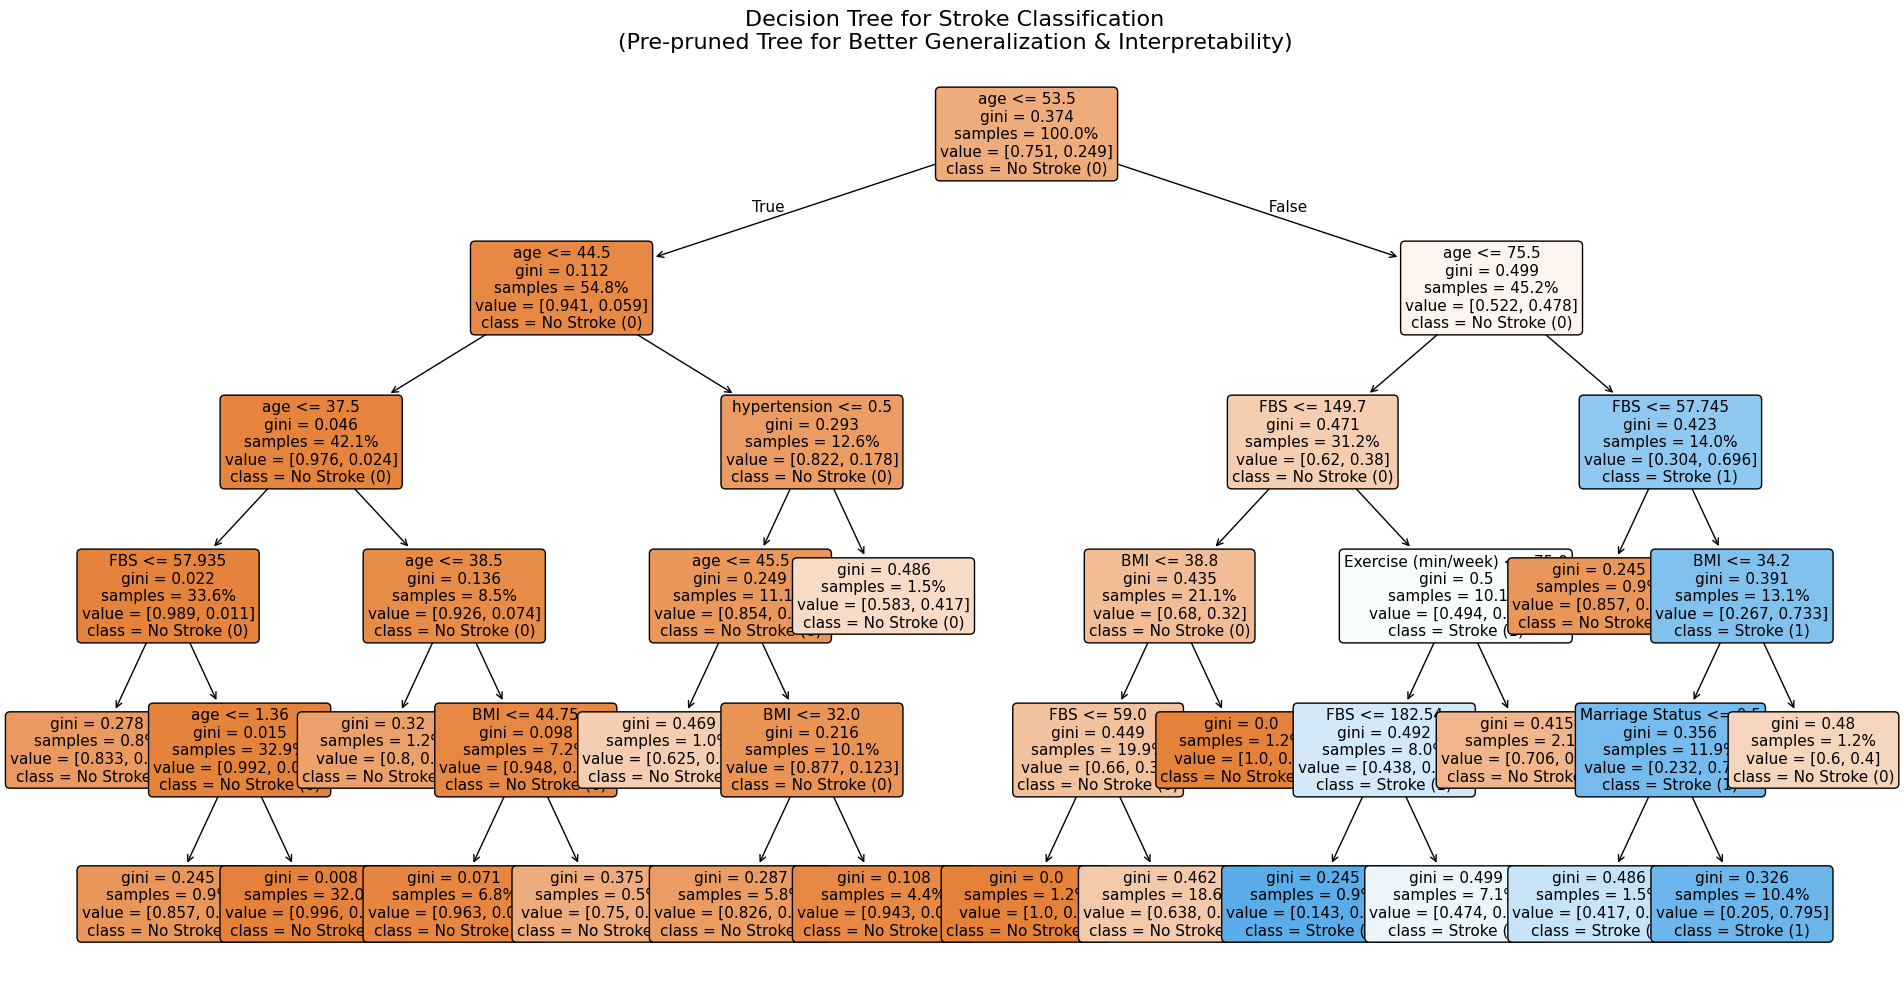

In [15]:
plt.figure(figsize=(24, 12))

plot_tree(
    final_model,
    feature_names=X.columns,
    class_names=["No Stroke (0)", "Stroke (1)"],
    filled=True,
    rounded=True,              # ทำให้โหนดมน อ่านง่าย
    proportion=True,           # แสดงสัดส่วนคลาส (เชิง entropy/gini)
    impurity=True,             # แสดงค่า gini / entropy
    fontsize=11
)

plt.title(
    "Decision Tree for Stroke Classification\n"
    "(Pre-pruned Tree for Better Generalization & Interpretability)",
    fontsize=16
)

plt.show()
